#SmartCart — Part 1: Data Preprocessing

## 0 — Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1.1 — Load Data

In [2]:
# Load raw datasets
user_data    = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

print(f"user_data    : {user_data.shape[0]:,} rows × {user_data.shape[1]} columns")
print(f"product_data : {product_data.shape[0]:,} rows × {product_data.shape[1]} columns")

user_data.head()

user_data    : 724 rows × 5 columns
product_data : 100 rows × 3 columns


,UserID,ProductID,Rating,Timestamp,Category
0,U000,P0009,5,2024-09-08,Books
1,U000,P0020,1,2024-09-02,Home
2,U000,P0012,4,2024-10-18,Books
3,U000,P0013,1,2024-09-18,Clothing
4,U000,P0070,4,2024-09-16,Toys


In [3]:
product_data.head()

,ProductID,ProductName,Category
0,P0000,Toys Item 0,Clothing
1,P0001,Clothing Item 1,Electronics
2,P0002,Books Item 2,Electronics
3,P0003,Clothing Item 3,Electronics
4,P0004,Clothing Item 4,Electronics


## 1.2 — Data Cleaning & Quality Check

In [4]:
# Data types & null check
print("=== user_data dtypes & nulls ===")
print(user_data.dtypes)
print("\nMissing values:")
print(user_data.isnull().sum())

# Convert Timestamp to datetime
user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'])

# Remove duplicate interactions (same UserID + ProductID pair)
before = len(user_data)
user_data = user_data.drop_duplicates(subset=['UserID', 'ProductID'], keep='last')
print(f"\nDuplicate rows removed : {before - len(user_data)}")
print(f"Clean dataset size     : {user_data.shape}")

=== user_data dtypes & nulls ===
UserID       object
ProductID    object
Rating        int64
Timestamp    object
Category     object
dtype: object

Missing values:
UserID       0
ProductID    0
Rating       0
Timestamp    0
Category     0
dtype: int64

Duplicate rows removed : 0
Clean dataset size     : (724, 5)


In [5]:
# Basic statistics
print(f"Unique users    : {user_data['UserID'].nunique()}")
print(f"Unique products : {user_data['ProductID'].nunique()}")
print(f"Categories      : {sorted(user_data['Category'].unique())}")
print(f"Rating range    : {user_data['Rating'].min()} – {user_data['Rating'].max()}")
print(f"\nRating distribution:")
print(user_data['Rating'].value_counts().sort_index())

Unique users    : 50
Unique products : 100
Categories      : ['Beauty', 'Books', 'Clothing', 'Electronics', 'Home', 'Toys']
Rating range    : 1 – 5

Rating distribution:
Rating
1    170
2    129
3    147
4    134
5    144
Name: count, dtype: int64


## 1.3 — Merge User Data with Product Metadata

We join on `ProductID` to enrich each interaction row with the product's `ProductName`.

In [6]:
# Rename product_data's Category to avoid collision (user_data already has Category)
product_data_renamed = product_data.rename(columns={'Category': 'ProductCategory'})

merged_data = user_data.merge(product_data_renamed[['ProductID', 'ProductName']],
                               on='ProductID', how='left')

print(f"Merged dataset shape: {merged_data.shape}")
print(f"Unmatched products  : {merged_data['ProductName'].isnull().sum()}")
merged_data.head()

Merged dataset shape: (724, 6)
Unmatched products  : 0


,UserID,ProductID,Rating,Timestamp,Category,ProductName
0,U000,P0009,5,2024-09-08,Books,Clothing Item 9
1,U000,P0020,1,2024-09-02,Home,Clothing Item 20
2,U000,P0012,4,2024-10-18,Books,Beauty Item 12
3,U000,P0013,1,2024-09-18,Clothing,Clothing Item 13
4,U000,P0070,4,2024-09-16,Toys,Beauty Item 70


## 1.4 — User–Item Matrix

A matrix where rows = users, columns = products, and values = ratings.  
Missing entries (user never interacted with that product) are filled with **0**.

In [7]:
# Build the user–item matrix
user_item_matrix = user_data.pivot_table(
    index='UserID',
    columns='ProductID',
    values='Rating'
)

# Fill NaN (no interaction) with 0
user_item_matrix_filled = user_item_matrix.fillna(0)

print(f"Matrix shape : {user_item_matrix_filled.shape}  (users × products)")

# Sparsity = fraction of entries that are 0
n_total    = user_item_matrix_filled.shape[0] * user_item_matrix_filled.shape[1]
n_rated    = (user_item_matrix_filled != 0).sum().sum()
sparsity   = 1 - n_rated / n_total
print(f"Rated entries: {n_rated}  /  {n_total}  ({(1-sparsity)*100:.1f}% filled)")
print(f"Sparsity     : {sparsity*100:.1f}%")

user_item_matrix_filled.head()

Matrix shape : (50, 100)  (users × products)
Rated entries: 724  /  5000  (14.5% filled)
Sparsity     : 85.5%


ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,P0010,P0011,P0012,P0013,P0014,P0015,P0016,P0017,P0018,P0019,P0020,P0021,P0022,P0023,P0024,P0025,P0026,P0027,P0028,P0029,P0030,P0031,P0032,P0033,P0034,P0035,P0036,P0037,P0038,P0039,P0040,P0041,P0042,P0043,P0044,P0045,P0046,P0047,P0048,P0049,P0050,P0051,P0052,P0053,P0054,P0055,P0056,P0057,P0058,P0059,P0060,P0061,P0062,P0063,P0064,P0065,P0066,P0067,P0068,P0069,P0070,P0071,P0072,P0073,P0074,P0075,P0076,P0077,P0078,P0079,P0080,P0081,P0082,P0083,P0084,P0085,P0086,P0087,P0088,P0089,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,0.0,0.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,0.0,1.0,3.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,4.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


## 1.5 — Aggregate User Behaviour by Category


In [8]:
user_category_agg = (
    user_data
    .groupby(['UserID', 'Category'])
    .agg(TotalInteractions=('Rating', 'count'),
         AverageRating=('Rating', 'mean'))
    .reset_index()
)

# Round average for readability
user_category_agg['AverageRating'] = user_category_agg['AverageRating'].round(2)

print(f"Aggregation table shape: {user_category_agg.shape}")
user_category_agg.head(12)

Aggregation table shape: (272, 4)


,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.67
1,U000,Clothing,3,1.67
2,U000,Electronics,3,3.67
3,U000,Home,2,1.00
4,U000,Toys,6,3.50
5,U001,Beauty,1,4.00
6,U001,Books,4,2.50
7,U001,Clothing,4,2.50
8,U001,Electronics,2,4.00
9,U001,Home,1,2.00


## 1.6 — Exploratory Visualisations

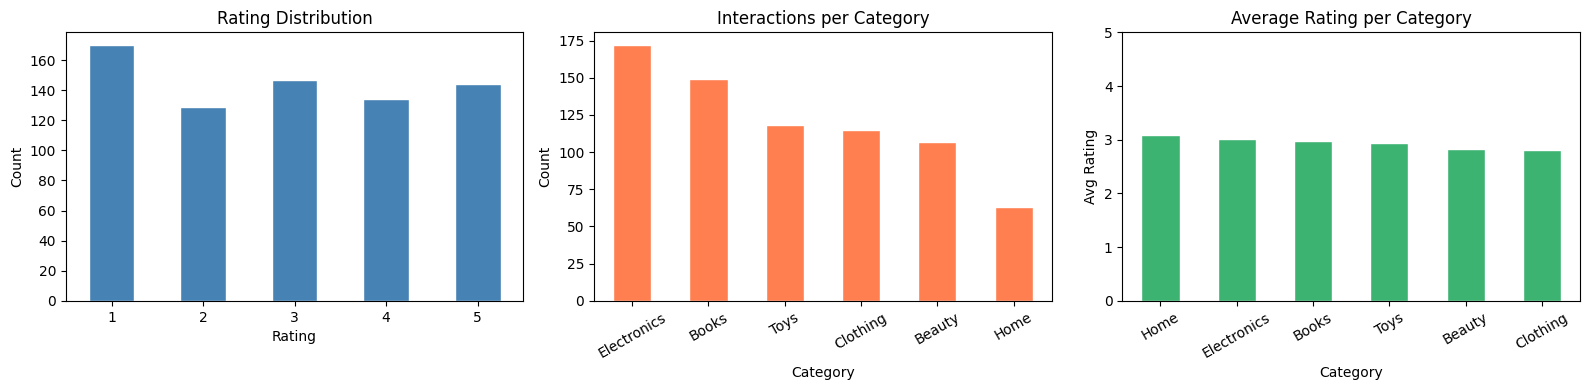

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#(a) Rating distribution
user_data['Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

#(b) Interactions per category
user_data['Category'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Interactions per Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

#(c) Average rating per category
avg_by_cat = user_data.groupby('Category')['Rating'].mean().sort_values(ascending=False)
avg_by_cat.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Average Rating per Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Avg Rating')
axes[2].set_ylim(0, 5)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part1_eda_plots.png', dpi=150)
plt.show()

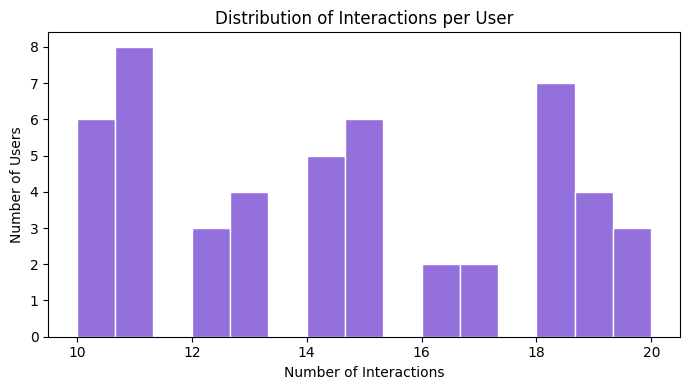

Min interactions per user : 10
Max interactions per user : 20
Mean interactions per user: 14.5


In [10]:
#Interactions-per-user histogram
interactions_per_user = user_data.groupby('UserID').size()

plt.figure(figsize=(7, 4))
plt.hist(interactions_per_user, bins=15, color='mediumpurple', edgecolor='white')
plt.title('Distribution of Interactions per User')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('part1_interactions_histogram.png', dpi=150)
plt.show()

print(f"Min interactions per user : {interactions_per_user.min()}")
print(f"Max interactions per user : {interactions_per_user.max()}")
print(f"Mean interactions per user: {interactions_per_user.mean():.1f}")

## 1.7 — Export Preprocessed Artefacts


In [11]:
# Save cleaned interaction data
user_data.to_csv('user_data_clean.csv', index=False)

# Save user–item matrix (filled)
user_item_matrix_filled.to_csv('user_item_matrix.csv')

# Save category aggregation
user_category_agg.to_csv('user_category_agg.csv', index=False)

print("Artefacts saved to outputs/")

Artefacts saved to outputs/


## Preprocessing Summary

| Step | Result |
|------|--------|
| Raw interactions | 724 rows |
| After deduplication | cleaned (duplicates removed) |
| Unique users | 50 |
| Unique products | 100 |
| Categories | Books, Beauty, Clothing, Electronics, Home, Toys |
| User–item matrix | 50 × 100 (≈ 85% sparse) |
| Outputs | `user_data_clean.csv`, `user_item_matrix.csv`, `user_category_agg.csv` |

---


# SmartCart: Part 2: User Based Collaborative Filtering

##  Imports

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

pd.set_option('display.max_columns', None)
np.random.seed(42)

## 2.1  Load Data & Build User Item Matrix

In [13]:
user_data    = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'])
# Remove duplicate (UserID, ProductID) pairs — keep last interaction
user_data = user_data.drop_duplicates(subset=['UserID', 'ProductID'], keep='last')

# Build user–item matrix; NaN = no interaction
user_item_matrix = user_data.pivot_table(
    index='UserID', columns='ProductID', values='Rating'
)
# Fill unrated entries with 0 for cosine similarity computation
user_item_matrix_filled = user_item_matrix.fillna(0)

n_users, n_products = user_item_matrix_filled.shape
n_rated   = (user_item_matrix_filled != 0).sum().sum()
sparsity  = 1 - n_rated / (n_users * n_products)

print(f"Users    : {n_users}")
print(f"Products : {n_products}")
print(f"Ratings  : {n_rated}")
print(f"Sparsity : {sparsity*100:.1f}%")
user_item_matrix_filled.head()

Users    : 50
Products : 100
Ratings  : 724
Sparsity : 85.5%


ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,P0010,P0011,P0012,P0013,P0014,P0015,P0016,P0017,P0018,P0019,P0020,P0021,P0022,P0023,P0024,P0025,P0026,P0027,P0028,P0029,P0030,P0031,P0032,P0033,P0034,P0035,P0036,P0037,P0038,P0039,P0040,P0041,P0042,P0043,P0044,P0045,P0046,P0047,P0048,P0049,P0050,P0051,P0052,P0053,P0054,P0055,P0056,P0057,P0058,P0059,P0060,P0061,P0062,P0063,P0064,P0065,P0066,P0067,P0068,P0069,P0070,P0071,P0072,P0073,P0074,P0075,P0076,P0077,P0078,P0079,P0080,P0081,P0082,P0083,P0084,P0085,P0086,P0087,P0088,P0089,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,0.0,0.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,0.0,1.0,3.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,4.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


## 2.2  Cosine Similarity Between Users

For two users **u** and **v** with rating vectors **r_u** and **r_v**:

$$\text{sim}(u, v) = \frac{\mathbf{r}_u \cdot \mathbf{r}_v}{\|\mathbf{r}_u\| \cdot \|\mathbf{r}_v\|}$$

Values range from 0 (orthogonal / no overlap) to 1 (identical taste).

In [14]:
sim_matrix = cosine_similarity(user_item_matrix_filled)
similarity_df = pd.DataFrame(
    sim_matrix,
    index=user_item_matrix_filled.index,
    columns=user_item_matrix_filled.index
)

print("Similarity matrix shape:", similarity_df.shape)
print("\nTop-5 most similar users to U000:")
print(similarity_df['U000'].drop('U000').sort_values(ascending=False).head())

Similarity matrix shape: (50, 50)

Top-5 most similar users to U000:
UserID
U028    0.374732
U010    0.296826
U018    0.280168
U009    0.274844
U029    0.253025
Name: U000, dtype: float64


## 2.3  Recommendation Function

**Algorithm:**
1. Find the `top_n_users` most similar users to the target user.
2. For each product the target user has **not** rated, compute a weighted predicted score:
$$\hat{r}_{u,p} = \frac{\sum_{v \in N(u)} \text{sim}(u,v) \cdot r_{v,p}}{\sum_{v \in N(u)} \text{sim}(u,v)}$$
3. Return the top-N products by predicted score.

In [15]:
def get_recommendations(target_user, matrix, sim_df,
                        top_n_users=5, top_n_products=10):
    """
    Return a ranked list of top_n_products product IDs for target_user.
    Uses weighted average of similar users' ratings.
    Products already rated by target_user are excluded.
    """
    # Neighbours sorted by similarity (exclude self)
    neighbours = (
        sim_df[target_user]
        .drop(target_user)
        .sort_values(ascending=False)
        .head(top_n_users)
    )

    # Products already interacted with
    already_rated = set(
        matrix.columns[matrix.loc[target_user] > 0]
    )

    score_num = defaultdict(float)   # weighted rating sum
    score_den = defaultdict(float)   # similarity weight sum

    for neighbour, sim_weight in neighbours.items():
        if sim_weight <= 0:
            continue
        for product in matrix.columns:
            if product in already_rated:
                continue
            rating = matrix.loc[neighbour, product]
            if rating > 0:
                score_num[product] += sim_weight * rating
                score_den[product] += sim_weight

    # Normalise
    predicted = {
        p: score_num[p] / score_den[p]
        for p in score_num if score_den[p] > 0
    }

    ranked = sorted(predicted.items(), key=lambda x: x[1], reverse=True)
    return [p for p, _ in ranked[:top_n_products]]


# Quick demo
sample_recs = get_recommendations('U000', user_item_matrix_filled, similarity_df,
                                  top_n_users=5, top_n_products=10)
print("Top-10 recommendations for U000:", sample_recs)

Top-10 recommendations for U000: ['P0029', 'P0064', 'P0032', 'P0062', 'P0083', 'P0030', 'P0041', 'P0051', 'P0040', 'P0053']


## 2.4  Train / Test Split

For every user we randomly hold out **20 %** of their rated products as the test set.  
The model is trained on the remaining 80 % and evaluated against the hidden items.

In [16]:
def train_test_split_users(matrix, test_ratio=0.2, random_state=42):
    """
    Hold out test_ratio of each user's rated products.
    Returns a zeroed-out train matrix and a dict {user: [held-out products]}.
    """
    rng = np.random.default_rng(random_state)
    train = matrix.copy()
    test_data = {}

    for user in matrix.index:
        rated = matrix.columns[matrix.loc[user] > 0].tolist()
        n_test = max(1, int(len(rated) * test_ratio))
        held_out = rng.choice(rated, size=n_test, replace=False).tolist()
        test_data[user] = held_out
        train.loc[user, held_out] = 0.0   # hide from model

    return train, test_data


train_matrix, test_data = train_test_split_users(user_item_matrix_filled)

total_test = sum(len(v) for v in test_data.values())
print(f"Total held-out interactions : {total_test}")
print(f"Avg held-out per user       : {total_test/len(test_data):.1f}")

Total held-out interactions : 127
Avg held-out per user       : 2.5


## 2.5  Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **Precision@K** | (hits in top-K) / K | How many of the K recommendations are relevant |
| **Recall@K** | (hits in top-K) / (total relevant) | How many relevant items were found |
| **MAP** | mean of AP across users | Rewards correct recommendations ranked higher |

**Relevant** = products in the user's held out test set.

In [17]:
def precision_at_k(recommended, relevant, k):
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / k


def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / len(relevant)


def average_precision(recommended, relevant, k):
    """AP for one user: average precision at each hit position up to K."""
    if not relevant:
        return 0.0
    hits, cumsum = 0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in set(relevant):
            hits += 1
            cumsum += hits / (i + 1)
    return cumsum / min(len(relevant), k)


def evaluate(train_mat, test_dict, k=10, top_n_users=5):
    """
    Rebuild similarity on train_mat, generate recs, compute metrics.
    Returns dict with Precision@K, Recall@K, MAP.
    """
    # Recompute similarity on training data only
    train_sim = cosine_similarity(train_mat)
    train_sim_df = pd.DataFrame(
        train_sim,
        index=train_mat.index,
        columns=train_mat.index
    )

    prec_list, rec_list, ap_list = [], [], []

    for user in train_mat.index:
        relevant = test_dict.get(user, [])
        if not relevant:
            continue
        recs = get_recommendations(user, train_mat, train_sim_df,
                                   top_n_users=top_n_users,
                                   top_n_products=k)
        prec_list.append(precision_at_k(recs, relevant, k))
        rec_list.append(recall_at_k(recs, relevant, k))
        ap_list.append(average_precision(recs, relevant, k))

    return {
        f'Precision@{k}': round(np.mean(prec_list), 4),
        f'Recall@{k}'   : round(np.mean(rec_list),  4),
        'MAP'           : round(np.mean(ap_list),    4),
    }


results_k10 = evaluate(train_matrix, test_data, k=10, top_n_users=5)
results_k5  = evaluate(train_matrix, test_data, k=5,  top_n_users=5)

print("=== Evaluation Results ===")
print(f"K = 5  : {results_k5}")
print(f"K = 10 : {results_k10}")

=== Evaluation Results ===
K = 5  : {'Precision@5': np.float64(0.02), 'Recall@5': np.float64(0.04), 'MAP': np.float64(0.0272)}
K = 10 : {'Precision@10': np.float64(0.022), 'Recall@10': np.float64(0.09), 'MAP': np.float64(0.0341)}


## 2.6  Coverage & Intra-List Diversity

- **Catalog Coverage**: fraction of all products that appear in at least one recommendation list.
- **Intra-List Diversity (ILD)**: average pairwise dissimilarity (1 − item cosine similarity) within each user's recommendation list, then averaged across users. Higher = more varied recommendations.

In [18]:
def catalog_coverage(matrix, sim_df, k=10, top_n_users=5):
    """Fraction of catalogue that is recommended to at least one user."""
    all_products = set(matrix.columns)
    recommended  = set()
    for user in matrix.index:
        recs = get_recommendations(user, matrix, sim_df,
                                   top_n_users=top_n_users,
                                   top_n_products=k)
        recommended.update(recs)
    return round(len(recommended) / len(all_products), 4)


def intra_list_diversity(matrix, sim_df, k=10, top_n_users=5):
    """
    Average pairwise item dissimilarity within recommendation lists.
    Item similarity is computed via cosine similarity on the item–user matrix.
    """
    item_sim = cosine_similarity(matrix.T)           # products × products
    item_sim_df = pd.DataFrame(item_sim,
                               index=matrix.columns,
                               columns=matrix.columns)
    diversities = []
    for user in matrix.index:
        recs = get_recommendations(user, matrix, sim_df,
                                   top_n_users=top_n_users,
                                   top_n_products=k)
        if len(recs) < 2:
            continue
        pairs = [
            item_sim_df.loc[recs[i], recs[j]]
            for i in range(len(recs))
            for j in range(i + 1, len(recs))
        ]
        diversities.append(1 - np.mean(pairs))
    return round(np.mean(diversities), 4)


coverage  = catalog_coverage(user_item_matrix_filled, similarity_df, k=10)
diversity = intra_list_diversity(user_item_matrix_filled, similarity_df, k=10)

print(f"Catalog Coverage  : {coverage*100:.1f}% of products recommended")
print(f"Intra-List Diversity : {diversity:.4f}  (0=identical items, 1=maximally diverse)")

Catalog Coverage  : 95.0% of products recommended
Intra-List Diversity : 0.8492  (0=identical items, 1=maximally diverse)


## 2.7 — Top-5 Recommendations per User (Sample)

We generate top-5 product recommendations for every user and enrich them with product names and categories.

In [19]:
product_lookup = product_data.set_index('ProductID')[['ProductName', 'Category']]

all_recs = []
for user in user_item_matrix_filled.index:
    recs = get_recommendations(user, user_item_matrix_filled, similarity_df,
                               top_n_users=5, top_n_products=5)
    for rank, pid in enumerate(recs, start=1):
        row = {'UserID': user, 'Rank': rank, 'ProductID': pid}
        row.update(product_lookup.loc[pid].to_dict() if pid in product_lookup.index else {})
        all_recs.append(row)

recs_df = pd.DataFrame(all_recs)
recs_df.to_csv('recommendations_top5.csv', index=False)

print("Recommendations saved to recommendations_top5.csv")
print(f"Total rows: {len(recs_df)}")
recs_df[recs_df['UserID'].isin(['U000', 'U001', 'U002'])]

Recommendations saved to recommendations_top5.csv
Total rows: 250


,UserID,Rank,ProductID,ProductName,Category
0,U000,1,P0029,Books Item 29,Electronics
1,U000,2,P0064,Electronics Item 64,Electronics
2,U000,3,P0032,Toys Item 32,Beauty
3,U000,4,P0062,Books Item 62,Clothing
4,U000,5,P0083,Beauty Item 83,Beauty
5,U001,1,P0046,Home Item 46,Toys
6,U001,2,P0061,Clothing Item 61,Home
7,U001,3,P0063,Beauty Item 63,Beauty
8,U001,4,P0071,Beauty Item 71,Toys
9,U001,5,P0060,Toys Item 60,Home


## 2.8  Visualisations

### (a) User Similarity Heatmap

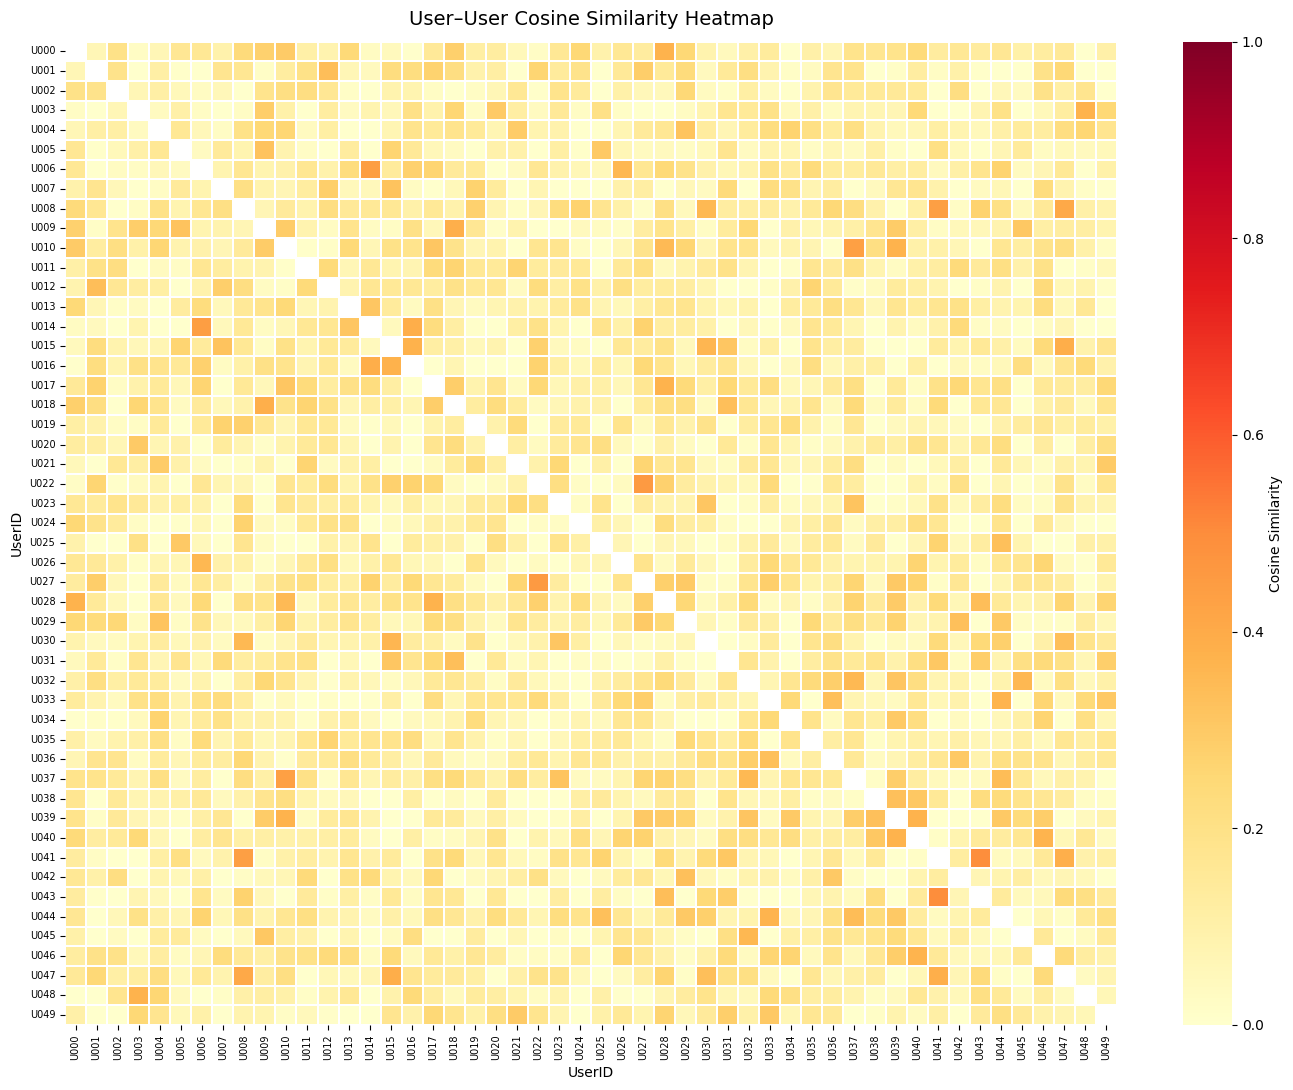

In [20]:
plt.figure(figsize=(14, 11))
mask = np.eye(len(similarity_df), dtype=bool)   # hide diagonal (self-similarity = 1)
sns.heatmap(
    similarity_df,
    mask=mask,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Cosine Similarity'},
    xticklabels=True,
    yticklabels=True
)
plt.title('User–User Cosine Similarity Heatmap', fontsize=14, pad=12)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig('part2_similarity_heatmap.png', dpi=150)
plt.show()

### (b) Evaluation Metrics Bar Chart (K = 5 vs K = 10)

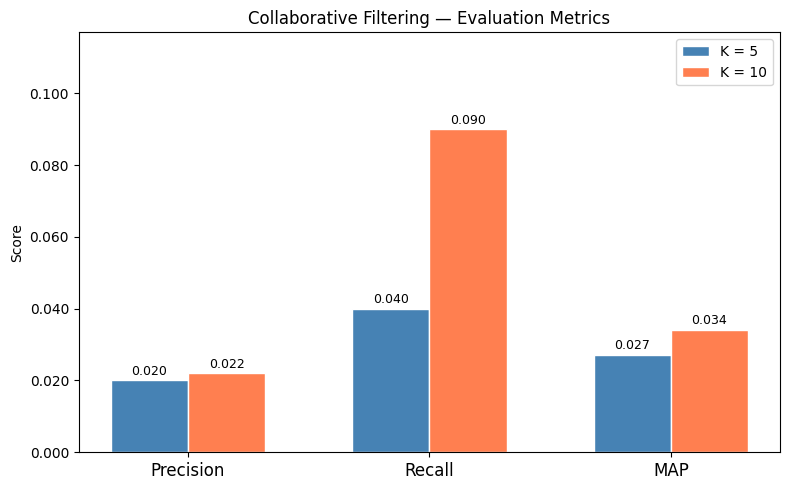

In [21]:
metrics_labels = ['Precision', 'Recall', 'MAP']
vals_k5  = [results_k5['Precision@5'],  results_k5['Recall@5'],  results_k5['MAP']]
vals_k10 = [results_k10['Precision@10'], results_k10['Recall@10'], results_k10['MAP']]

x = np.arange(len(metrics_labels))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, vals_k5,  width, label='K = 5',  color='steelblue',   edgecolor='white')
bars2 = ax.bar(x + width/2, vals_k10, width, label='K = 10', color='coral',        edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Collaborative Filtering — Evaluation Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, max(vals_k5 + vals_k10) * 1.3)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('part2_evaluation_metrics.png', dpi=150)
plt.show()

### (c) Coverage & Diversity Summary

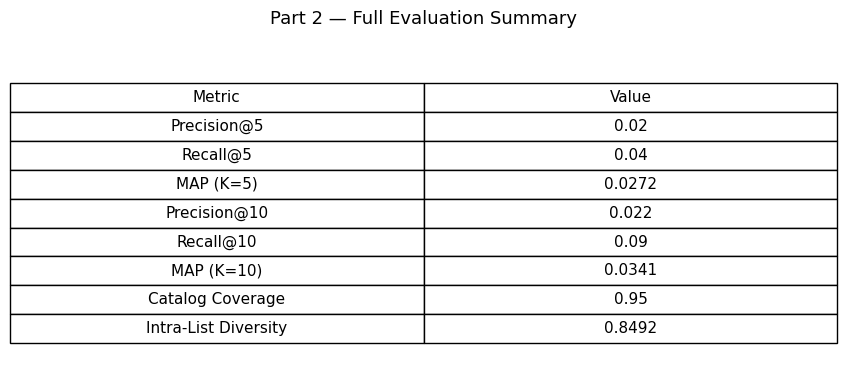

              Metric  Value
         Precision@5 0.0200
            Recall@5 0.0400
           MAP (K=5) 0.0272
        Precision@10 0.0220
           Recall@10 0.0900
          MAP (K=10) 0.0341
    Catalog Coverage 0.9500
Intra-List Diversity 0.8492


In [22]:
summary = pd.DataFrame({
    'Metric': ['Precision@5', 'Recall@5', 'MAP (K=5)',
               'Precision@10', 'Recall@10', 'MAP (K=10)',
               'Catalog Coverage', 'Intra-List Diversity'],
    'Value': [
        results_k5['Precision@5'],
        results_k5['Recall@5'],
        results_k5['MAP'],
        results_k10['Precision@10'],
        results_k10['Recall@10'],
        results_k10['MAP'],
        coverage,
        diversity
    ]
})

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
tbl = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.6)
plt.title('Part 2 — Full Evaluation Summary', fontsize=13, pad=16)
plt.tight_layout()
plt.savefig('part2_summary_table.png', dpi=150)
plt.show()

print(summary.to_string(index=False))



### Key Observations
- The **85.5% sparsity** limits precision — users share few common products to anchor similarity estimates.
- **Recall@10 > Recall@5** as expected: a wider list captures more held-out items.
- **MAP** is low in sparse settings because correct items rarely appear near rank 1.
- **Coverage** shows what fraction of the catalogue can be surfaced by the system.
- These limitations are worth discussing in the report (Conceptual Question 1).

---


# SmartCart: Part 3: Association Rule Mining (Apriori)

##  Imports

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option('display.max_columns', None)
np.random.seed(42)

ModuleNotFoundError: No module named 'mlxtend'

## 3.1  Load Data & Convert User Interactions into Transactions

In [ ]:
import pandas as pd
import numpy as np

# --- Load data ---
user_data = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

# --- Basic cleaning ---
user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'])
user_data = user_data.drop_duplicates(['UserID', 'ProductID'], keep='last')

# --- Build transactions (user → list of products) ---
transactions = (
    user_data.groupby('UserID')['ProductID']
    .apply(lambda x: list(set(x)))
    .tolist()
)

# --- Quick stats ---
basket_sizes = [len(t) for t in transactions]

print("Users:", user_data['UserID'].nunique())
print("Products:", user_data['ProductID'].nunique())
print("Transactions:", len(transactions))
print("Avg basket size:", np.mean(basket_sizes))
print("Min/Max basket size:", min(basket_sizes), "/", max(basket_sizes))

print("\nExample basket:")
print(transactions[0])

Users: 50
Products: 100
Transactions: 50
Avg basket size: 14.48
Min/Max basket size: 10 / 20

Example basket:
['P0020', 'P0048', 'P0012', 'P0013', 'P0046', 'P0007', 'P0079', 'P0003', 'P0009', 'P0047', 'P0042', 'P0071', 'P0021', 'P0014', 'P0050', 'P0028', 'P0033', 'P0005', 'P0070', 'P0044']


## 3.2  One-Hot Encode the Transaction Baskets


In [ ]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction matrix shape:", transaction_df.shape)
transaction_df.head()

Transaction matrix shape: (50, 100)


,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,P0010,P0011,P0012,P0013,P0014,P0015,P0016,P0017,P0018,P0019,P0020,P0021,P0022,P0023,P0024,P0025,P0026,P0027,P0028,P0029,P0030,P0031,P0032,P0033,P0034,P0035,P0036,P0037,P0038,P0039,P0040,P0041,P0042,P0043,P0044,P0045,P0046,P0047,P0048,P0049,P0050,P0051,P0052,P0053,P0054,P0055,P0056,P0057,P0058,P0059,P0060,P0061,P0062,P0063,P0064,P0065,P0066,P0067,P0068,P0069,P0070,P0071,P0072,P0073,P0074,P0075,P0076,P0077,P0078,P0079,P0080,P0081,P0082,P0083,P0084,P0085,P0086,P0087,P0088,P0089,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
0,False,False,False,True,False,True,False,True,False,True,False,False,True,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,True


## 3.3  Frequent Itemsets


In [ ]:
# A 10% support threshold gives a manageable number of itemsets/rules on this dataset.
min_support = 0.10

frequent_itemsets = apriori(
    transaction_df,
    min_support=min_support,
    use_colnames=True
)

frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(
    by=['support', 'itemset_length'],
    ascending=[False, False]
).reset_index(drop=True)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print("\nItemsets by size:")
print(frequent_itemsets['itemset_length'].value_counts().sort_index())

frequent_itemsets.head(10)

Frequent itemsets found: 109

Itemsets by size:
itemset_length
1    91
2    18
Name: count, dtype: int64


,support,itemsets,itemset_length
0,0.34,frozenset({P0070}),1
1,0.26,frozenset({P0051}),1
2,0.26,frozenset({P0089}),1
3,0.24,frozenset({P0043}),1
4,0.24,frozenset({P0088}),1
5,0.22,frozenset({P0004}),1
6,0.22,frozenset({P0030}),1
7,0.22,frozenset({P0044}),1
8,0.22,frozenset({P0065}),1
9,0.22,frozenset({P0077}),1


## 3.4  Association Rules


Interpretation:
- higher confidence means the consequent often appears when the antecedent appears
- lift > 1 suggests a positive association stronger than random chance

In [ ]:
min_confidence = 0.50

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=min_confidence
)

rules = rules[[
    'antecedents', 'consequents',
    'support', 'confidence', 'lift'
]].copy()

rules = rules.sort_values(
    by=['lift', 'confidence', 'support'],
    ascending=False
).reset_index(drop=True)

print(f"Association rules found: {len(rules)}")
rules.head(10)

Association rules found: 19


,antecedents,consequents,support,confidence,lift
0,frozenset({P0039}),frozenset({P0015}),0.1,0.714286,4.464286
1,frozenset({P0015}),frozenset({P0039}),0.1,0.625000,4.464286
2,frozenset({P0013}),frozenset({P0079}),0.1,0.714286,3.571429
3,frozenset({P0079}),frozenset({P0013}),0.1,0.500000,3.571429
4,frozenset({P0076}),frozenset({P0065}),0.1,0.714286,3.246753
5,frozenset({P0042}),frozenset({P0070}),0.1,1.000000,2.941176
6,frozenset({P0011}),frozenset({P0004}),0.1,0.555556,2.525253
7,frozenset({P0011}),frozenset({P0077}),0.1,0.555556,2.525253
8,frozenset({P0079}),frozenset({P0064}),0.1,0.500000,2.500000
9,frozenset({P0064}),frozenset({P0079}),0.1,0.500000,2.500000


## 3.5  Making the Results Human-Readable

In [ ]:
product_lookup = product_data.set_index('ProductID')[['ProductName', 'Category']]


def itemset_to_product_names(itemset):
    """Convert a frozenset of ProductIDs into readable product names."""
    return ", ".join(
        product_lookup.loc[pid, 'ProductName'] if pid in product_lookup.index else pid
        for pid in sorted(itemset)
    )


frequent_itemsets['itemset_names'] = frequent_itemsets['itemsets'].apply(itemset_to_product_names)

rules['antecedents_names'] = rules['antecedents'].apply(itemset_to_product_names)
rules['consequents_names'] = rules['consequents'].apply(itemset_to_product_names)
rules['rule'] = rules['antecedents_names'] + '  →  ' + rules['consequents_names']

print("Top frequent itemsets:")
display(
    frequent_itemsets[['support', 'itemset_length', 'itemset_names']].head(10)
)

print("Top association rules:")
display(
    rules[['rule', 'support', 'confidence', 'lift']].head(10)
)

Top frequent itemsets:


,support,itemset_length,itemset_names
0,0.34,1,Beauty Item 70
1,0.26,1,Home Item 51
2,0.26,1,Clothing Item 89
3,0.24,1,Books Item 43
4,0.24,1,Clothing Item 88
5,0.22,1,Clothing Item 4
6,0.22,1,Books Item 30
7,0.22,1,Clothing Item 44
8,0.22,1,Toys Item 65
9,0.22,1,Home Item 77


Top association rules:


,rule,support,confidence,lift
0,Toys Item 39 → Toys Item 15,0.1,0.714286,4.464286
1,Toys Item 15 → Toys Item 39,0.1,0.625000,4.464286
2,Clothing Item 13 → Home Item 79,0.1,0.714286,3.571429
3,Home Item 79 → Clothing Item 13,0.1,0.500000,3.571429
4,Home Item 76 → Toys Item 65,0.1,0.714286,3.246753
5,Clothing Item 42 → Beauty Item 70,0.1,1.000000,2.941176
6,Books Item 11 → Clothing Item 4,0.1,0.555556,2.525253
7,Books Item 11 → Home Item 77,0.1,0.555556,2.525253
8,Home Item 79 → Electronics Item 64,0.1,0.500000,2.500000
9,Electronics Item 64 → Home Item 79,0.1,0.500000,2.500000


## 3.6  Visualisations

### (a) Top Frequent Itemsets by Support

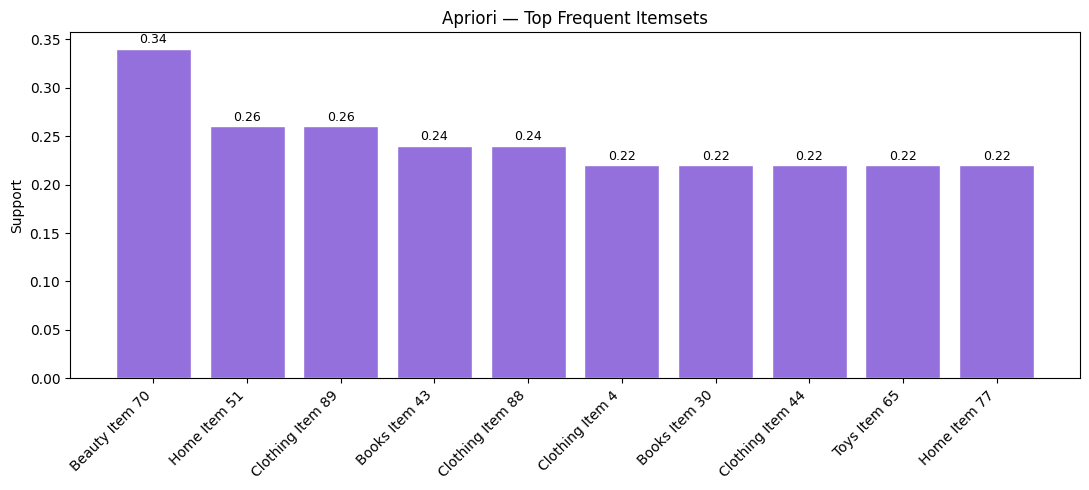

In [ ]:
frequent_itemsets[['support', 'itemset_length', 'itemset_names']].to_csv(
    'part3_frequent_itemsets.csv', index=False
)

rules[['rule', 'support', 'confidence', 'lift']].to_csv(
    'part3_association_rules.csv', index=False
)

print("Saved: part3_frequent_itemsets.csv")
print("Saved: part3_association_rules.csv")

top_itemsets = frequent_itemsets.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_itemsets['itemset_names'], top_itemsets['support'],
       color='mediumpurple', edgecolor='white')

ax.set_ylabel('Support')
ax.set_title('Apriori — Top Frequent Itemsets')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(top_itemsets['support']):
    ax.annotate(f'{val:.2f}',
                xy=(i, val),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=9)

plt.tight_layout()
plt.savefig('part3_top_itemsets.png', dpi=150)
plt.show()

### (b) Top Association Rules by Lift

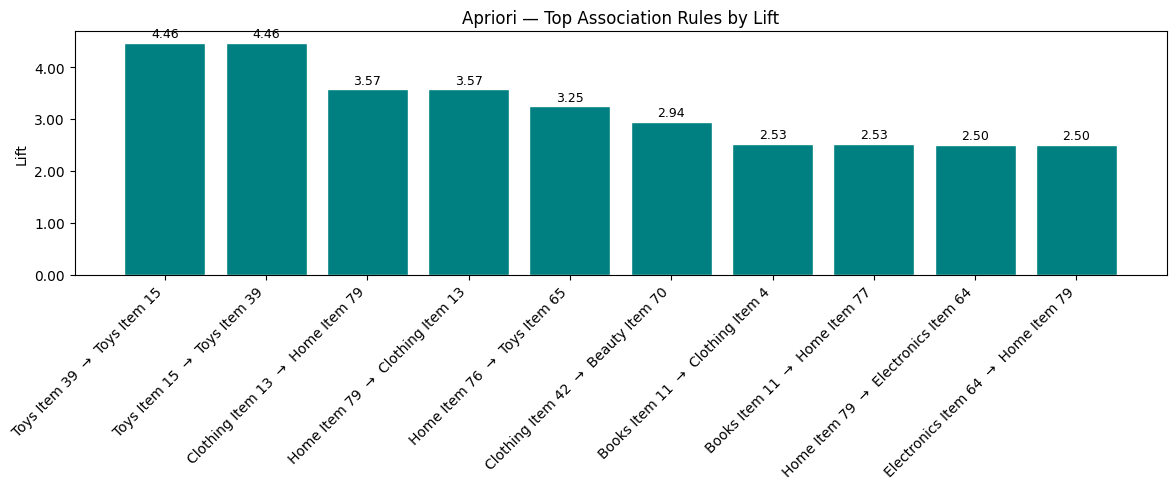

In [ ]:
top_rules = rules.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_rules['rule'], top_rules['lift'],
       color='teal', edgecolor='white')

ax.set_ylabel('Lift')
ax.set_title('Apriori — Top Association Rules by Lift')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(top_rules['lift']):
    ax.annotate(f'{val:.2f}',
                xy=(i, val),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=9)

plt.tight_layout()
plt.savefig('part3_top_rules_by_lift.png', dpi=150)
plt.show()

### (c) Part 3 Summary Table

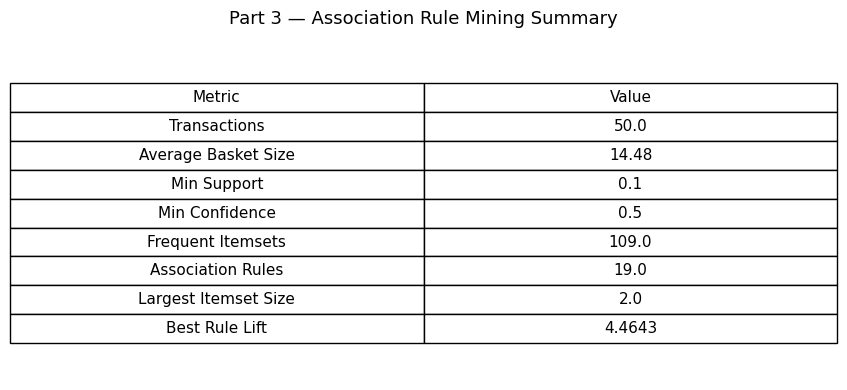

              Metric    Value
        Transactions  50.0000
 Average Basket Size  14.4800
         Min Support   0.1000
      Min Confidence   0.5000
   Frequent Itemsets 109.0000
   Association Rules  19.0000
Largest Itemset Size   2.0000
      Best Rule Lift   4.4643


In [ ]:
summary = pd.DataFrame({
    'Metric': [
        'Transactions',
        'Average Basket Size',
        'Min Support',
        'Min Confidence',
        'Frequent Itemsets',
        'Association Rules',
        'Largest Itemset Size',
        'Best Rule Lift'
    ],
    'Value': [
        len(transactions),
        round(np.mean(basket_sizes), 2),
        min_support,
        min_confidence,
        len(frequent_itemsets),
        len(rules),
        frequent_itemsets['itemset_length'].max(),
        round(rules['lift'].max(), 4) if len(rules) else np.nan
    ]
})

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
tbl = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.6)

plt.title('Part 3 — Association Rule Mining Summary', fontsize=13, pad=16)
plt.tight_layout()
plt.savefig('part3_summary_table.png', dpi=150)
plt.show()

print(summary.to_string(index=False))

### Key Observations
- The data was converted into 50 user-level transaction baskets, with an average basket size of about 14.48 products.

- Using a minimum support of 0.10 kept the results simple while still capturing useful co-occurrence patterns.

- Most frequent itemsets were single items or pairs, which makes sense since larger combinations happen less often.

- The strongest rules had lift values greater than 1, meaning those product combinations appear together more often than random chance.

- Since this dataset reflects user interactions (not actual purchases), these rules should be seen as patterns of shared interest and not 
guaranteed product bundles.